# Проект: создание рекомендательной системы для сервиса Яндекс Музыка

Цель проекта - построить прототип персональной рекомендательной системы для музыкального стримингового сервиса на основе истории взаимодействий пользователей с треками.

# Описание данных

Используются три исходных набора данных:

- `tracks.parquet` - информация об 1 млн музыкальных треков, их альбомах, исполнителях и жанрах;
- `catalog_names.parquet` - названия треков, альбомов, исполнителей и жанров;
- `interactions.parquet` - история прослушиваний пользователей.

# Инициализация

Загружаем библиотеки, необходимые для выполнения кода ноутбука.

In [1]:
# импортируем стандартные библиотеки для работы с путями и управления памятью
from pathlib import Path
import gc

# импортируем библиотеки для обработки табличных данных
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

# импортируем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# импортируем библиотеки для работы с окружением и S3
import os
import boto3
from dotenv import load_dotenv

In [2]:
# также сразу настраиваем отображение таблиц в ноутбуке
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.options.display.float_format = "{:.2f}".format

Необходимые библиотеки для загрузки, обработки и визуального анализа данных успешно импортированы. Дополнительно подключены инструменты для работы с parquet-файлами и контроля памяти, что важно из-за большого объёма данных о взаимодействиях пользователей. Переходим к загрузке и ознакомлению с данными.

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

На этом этапе загружаем исходные данные и сразу учитываем их объём. Таблицы `tracks` и `catalog_names` читаем полностью, так как они относительно компактны и нужны для проверки связей между треками и каталожными сущностями. Файл `interactions.parquet` значительно крупнее, поэтому пока не загружаем его целиком в память, а работаем с его метаданными через PyArrow.

In [3]:
# задаём пути к исходным файлам с данными
tracks_path = Path("tracks.parquet")
catalog_names_path = Path("catalog_names.parquet")
interactions_path = Path("interactions.parquet")

In [4]:
# загружаем таблицы с информацией о треках и каталогах
tracks = pd.read_parquet(tracks_path)
catalog_names = pd.read_parquet(catalog_names_path)

In [5]:
# создаём объект для работы с большим файлом взаимодействий без полной загрузки в память
interactions_parquet = pq.ParquetFile(interactions_path)

In [6]:
# выводим размеры загруженных данных
print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
print("interactions:",
    (
        interactions_parquet.metadata.num_rows,
        interactions_parquet.metadata.num_columns,
    ),
)

tracks: (1000000, 4)
catalog_names: (1812471, 3)
interactions: (222629898, 5)


Таблицы `tracks` и `catalog_names` успешно загружены полностью, а для `interactions` получена информация о размере без полной загрузки в память. Набор взаимодействий содержит 222 629 898 строк и 5 столбцов, поэтому дальнейшую работу с ним будем организовывать аккуратно, чтобы не создавать лишнюю нагрузку на память.

# Обзор данных

Проверим структуру и типы данных в исходных таблицах. Особое внимание уделим идентификаторам пользователей, треков, альбомов, исполнителей и жанров, чтобы понять, требуется ли их преобразование перед дальнейшей обработкой.

In [7]:
# выводим типы данных в таблицах с треками и каталожными сущностями
print("tracks:")
print(tracks.dtypes)
print("\ncatalog_names:")
print(catalog_names.dtypes)

tracks:
track_id     int64
albums      object
artists     object
genres      object
dtype: object

catalog_names:
id       int64
type    object
name    object
dtype: object


In [8]:
# выводим схему большого файла взаимодействий без полной загрузки в память
print("interactions:")
print(interactions_parquet.schema_arrow)

interactions:
user_id: int32
track_id: int32
track_seq: int16
started_at: timestamp[ns]
__index_level_0__: int64
-- schema metadata --
pandas: '{"index_columns": ["__index_level_0__"], "column_indexes": [{"na' + 797


Также посмотрим на первые строки в таблицах.

In [9]:
# выводим первые строки таблицы с треками
display(tracks.head())

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 2490809, 6007655, 17294156]",[84],[11]


In [10]:
# выводим первые строки таблицы с названиями каталожных сущностей
display(catalog_names.head())

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


In [11]:
# читаем небольшой фрагмент взаимодействий без полной загрузки файла в память
interactions_sample = interactions_parquet.read_row_group(0).to_pandas().head()

# выводим первые строки таблицы взаимодействий
display(interactions_sample)

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


В таблице `tracks` каждому треку соответствуют списки идентификаторов альбомов, исполнителей и жанров. Сами идентификаторы треков хранятся в типе `int64`. Таблица `catalog_names` содержит идентификатор сущности, её тип и название, а `interactions` последовательность прослушиваний пользователей с идентификаторами пользователей и треков, порядковым номером взаимодействия и датой начала прослушивания. В `interactions` идентификаторы уже имеют компактный тип `int32`, тогда как в `tracks` и `catalog_names` используются `int64`, поэтому следующим шагом проверим диапазон значений и решим, требуется ли преобразование типов. Для этого проверим минимальные и максимальные значения идентификаторов в таблицах `tracks` и `catalog_names`. Это позволит определить, укладываются ли значения в диапазон `int32` и можно ли привести идентификаторы к более компактному типу без потери данных.

In [12]:
# проверяем диапазон идентификаторов треков
print("tracks.track_id:")
print("min:", tracks["track_id"].min())
print("max:", tracks["track_id"].max())

tracks.track_id:
min: 26
max: 101521819


In [13]:
# проверяем диапазон идентификаторов каталожных сущностей
print("\ncatalog_names.id:")
print("min:", catalog_names["id"].min())
print("max:", catalog_names["id"].max())


catalog_names.id:
min: 0
max: 101521819


In [14]:
# выводим допустимый диапазон типа int32
int32_info = np.iinfo(np.int32)
print("\nint32 range:")
print("min:", int32_info.min)
print("max:", int32_info.max)


int32 range:
min: -2147483648
max: 2147483647


Максимальные значения идентификаторов в `tracks` и `catalog_names` значительно меньше верхней границы типа `int32`. Поэтому `track_id` и `id` можно безопасно привести из `int64` к `int32` без потери данных. Это также уменьшит потребление памяти и приведёт типы идентификаторов к формату, уже используемому в `interactions`.

In [15]:
# приводим идентификатор трека к более компактному типу
tracks["track_id"] = tracks["track_id"].astype("int32")

In [16]:
# приводим идентификатор каталожной сущности к более компактному типу
catalog_names["id"] = catalog_names["id"].astype("int32")

In [17]:
# делаем проверку
print("tracks.track_id:", tracks["track_id"].dtype)
print("catalog_names.id:", catalog_names["id"].dtype)

tracks.track_id: int32
catalog_names.id: int32


Идентификаторы `track_id` и `id` успешно приведены к типу `int32`. Теперь типы идентификаторов согласованы между таблицами, а хранение данных стало более компактным без потери информации.

Далее проверим состав каталога и убедимся, какие типы сущностей представлены в `catalog_names`. Это необходимо перед проверкой соответствия альбомов, исполнителей и жанров из `tracks` справочнику каталога.

In [18]:
# выводим уникальные типы каталожных сущностей
print(catalog_names["type"].value_counts())

type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64


В `catalog_names` представлены все основные типы сущностей, используемые в данных: треки, альбомы, исполнители и жанры. Это позволяет проверить, все ли идентификаторы альбомов, исполнителей и жанров из таблицы `tracks` имеют соответствующие записи в каталоге. Теперь сравним идентификаторы альбомов, исполнителей и жанров из `tracks` с соответствующими идентификаторами в `catalog_names`. Идентификаторы, отсутствующие в каталоге, будем считать неизвестными.

In [19]:
# формируем множества идентификаторов сущностей из каталога
catalog_album_ids = set(catalog_names.loc[catalog_names["type"] == "album", "id"])
catalog_artist_ids = set(catalog_names.loc[catalog_names["type"] == "artist", "id"])
catalog_genre_ids = set(catalog_names.loc[catalog_names["type"] == "genre", "id"])

In [20]:
# собираем уникальные идентификаторы сущностей, используемые в треках
track_album_ids = {item_id for ids in tracks["albums"] for item_id in ids}
track_artist_ids = {item_id for ids in tracks["artists"] for item_id in ids}
track_genre_ids = {item_id for ids in tracks["genres"] for item_id in ids}

In [21]:
# находим идентификаторы, отсутствующие в каталоге
unknown_album_ids = track_album_ids - catalog_album_ids
unknown_artist_ids = track_artist_ids - catalog_artist_ids
unknown_genre_ids = track_genre_ids - catalog_genre_ids

In [22]:
# выводим количество неизвестных сущностей
print("неизвестные альбомы:", len(unknown_album_ids))
print("неизвестные исполнители:", len(unknown_artist_ids))
print("неизвестные жанры:", len(unknown_genre_ids))

неизвестные альбомы: 0
неизвестные исполнители: 0
неизвестные жанры: 30


Неизвестных альбомов и исполнителей не обнаружено: все их идентификаторы присутствуют в `catalog_names`. Для жанров найдено 30 идентификаторов, отсутствующих в каталоге, поэтому следующим шагом проверим, какие именно это значения и насколько часто они встречаются в треках.

In [23]:
# выводим идентификаторы неизвестных жанров
print("unknown genre ids:")
print(sorted(unknown_genre_ids))

unknown genre ids:
[124, 126, 130, 131, 132, 133, 134, 135, 146, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169]


In [24]:
# считаем, сколько треков содержат каждый неизвестный жанр
unknown_genre_counts = {}
for genre_ids in tracks["genres"]:
    for genre_id in genre_ids:
        if genre_id in unknown_genre_ids:
            unknown_genre_counts[genre_id] = unknown_genre_counts.get(genre_id, 0) + 1

In [25]:
# выводим частоту встречаемости неизвестных жанров
print(
    sorted(
        unknown_genre_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

[(154, 8170), (161, 6750), (163, 5351), (158, 4867), (157, 3994), (151, 3387), (169, 2780), (155, 2288), (159, 2087), (164, 1961), (156, 1560), (162, 962), (168, 789), (153, 704), (160, 601), (165, 409), (146, 338), (167, 336), (131, 256), (152, 245), (126, 136), (130, 107), (132, 106), (134, 91), (135, 39), (133, 27), (166, 20), (148, 4), (124, 2), (150, 2)]


Неизвестные жанры встречаются с разной частотой: некоторые из них указаны у нескольких тысяч треков. Поэтому перед корректировкой данных проверим, сколько треков затронуто и есть ли среди них треки, для которых все жанры являются неизвестными.

In [26]:
# определяем треки, содержащие хотя бы один неизвестный жанр
has_unknown_genre = tracks["genres"].apply(lambda genre_ids: any(genre_id in unknown_genre_ids for genre_id in genre_ids))

In [27]:
# определяем треки, у которых нет ни одного известного жанра
has_only_unknown_genres = tracks["genres"].apply(
    lambda genre_ids: (
        len(genre_ids) > 0
        and all(genre_id in unknown_genre_ids for genre_id in genre_ids)
    )
)

In [28]:
# выводим количество затронутых треков
print("Треков с неизвестными жанрами:", has_unknown_genre.sum())
print("Треков только с неизвестными жанрами:", has_only_unknown_genres.sum())

Треков с неизвестными жанрами: 48345
Треков только с неизвестными жанрами: 7


Неизвестные жанры встречаются у 48345 треков, однако только у 7 треков все указанные жанры отсутствуют в каталоге. Следовательно, для подавляющего большинства затронутых треков можно удалить неизвестные идентификаторы, сохранив при этом корректную жанровую информацию. Но для начала проверим, есть ли в исходных данных треки с пустым списком жанров. Это поможет решить, как корректно обработать данные 7 треков.

In [29]:
# проверяем количество треков без указанных жанров
tracks_without_genres = tracks["genres"].apply(len).eq(0).sum()
print("Треков без указанных жанров:", tracks_without_genres)

Треков без указанных жанров: 3687


В исходных данных уже присутствуют 3687 треков без указанных жанров. Поэтому для 7 треков, содержащих только неизвестные жанры, после удаления некорректных идентификаторов допустимо оставить пустой список жанров, не вводя искусственную категорию.

In [30]:
# удаляем неизвестные идентификаторы жанров, сохраняя все известные жанры
tracks["genres"] = tracks["genres"].apply(
    lambda genre_ids: [
        genre_id
        for genre_id in genre_ids
        if genre_id not in unknown_genre_ids
    ]
)

In [31]:
# повторно проверяем наличие неизвестных жанров после очистки
remaining_unknown_genres = {
    genre_id
    for genre_ids in tracks["genres"]
    for genre_id in genre_ids
    if genre_id not in catalog_genre_ids
}

In [32]:
# проверяем количество треков без жанров после очистки и выводим результат
tracks_without_genres_after = tracks["genres"].apply(len).eq(0).sum()
print("Неизвестных жанров после очистки:", len(remaining_unknown_genres))
print("Треков без указанных жанров после очистки:", tracks_without_genres_after)

Неизвестных жанров после очистки: 0
Треков без указанных жанров после очистки: 3694


Неизвестные идентификаторы жанров успешно удалены: после очистки их количество равно нулю. Число треков без жанров увеличилось с 3687 до 3694, то есть ровно на 7 треков, у которых до очистки были указаны только неизвестные жанры.

Проведём финальную проверку соответствия альбомов, исполнителей и жанров каталогу после очистки. Это позволит убедиться, что в данных больше не осталось неизвестных идентификаторов сущностей.

In [33]:
# повторно собираем уникальные идентификаторы сущностей из треков
track_album_ids = {item_id for ids in tracks["albums"] for item_id in ids}
track_artist_ids = {item_id for ids in tracks["artists"] for item_id in ids}
track_genre_ids = {item_id for ids in tracks["genres"] for item_id in ids}

In [34]:
# повторно проверяем неизвестные идентификаторы
unknown_album_ids = track_album_ids - catalog_album_ids
unknown_artist_ids = track_artist_ids - catalog_artist_ids
unknown_genre_ids = track_genre_ids - catalog_genre_ids

In [35]:
# выводим результаты контрольной проверки
print("Неизвестных альбомов:", len(unknown_album_ids))
print("Неизвестных исполнителей:", len(unknown_artist_ids))
print("Неизвестных жанров:", len(unknown_genre_ids))

Неизвестных альбомов: 0
Неизвестных исполнителей: 0
Неизвестных жанров: 0


После очистки неизвестных сущностей не осталось: все идентификаторы альбомов, исполнителей и жанров из `tracks` присутствуют в `catalog_names`. Таким образом, проблема несогласованности справочника и данных устранена.

# Выводы

- На этапе первичного знакомства с данными были проверены: структура таблиц, типы идентификаторов и согласованность связей между треками и сущностями в каталогах.
- Идентификаторы `track_id` в `tracks` и `id` в `catalog_names` изначально имели тип `int64`. Проверка диапазона значений показала, что они полностью укладываются в `int32`, поэтому были безопасно приведены к более компактному типу без потери данных. В `interactions` идентификаторы уже хранятся в `int32`.
- Для альбомов и исполнителей неизвестных идентификаторов не обнаружено. Для жанров было найдено 30 идентификаторов, отсутствующих в `catalog_names`. Они встречались у 48345 треков, причём только у 7 треков все жанры были неизвестными. Неизвестные жанровые идентификаторы были удалены, при этом корректные жанры сохранены. После очистки неизвестных альбомов, исполнителей и жанров не осталось.

Таким образом, основные проблемы первичных данных были выявлены и устранены, а данные подготовлены к дальнейшему исследовательскому анализу (EDA).

# === ЭТАП 2 ===

# EDA

## Распределение количества прослушанных треков

Для анализа активности пользователей посчитаем количество прослушанных треков для каждого пользователя. Поскольку таблица `interactions` содержит более 222 млн строк, обработаем её пакетами и будем читать только столбец `user_id`, чтобы не загружать весь набор данных в память.

In [36]:
# создаём счётчик количества взаимодействий для каждого пользователя
user_listen_counts = pd.Series(dtype="int64")

In [37]:
# последовательно читаем только идентификаторы пользователей небольшими пакетами
for batch in interactions_parquet.iter_batches(
    batch_size=1000000,
    columns=["user_id"]
):
    batch_users = batch.column("user_id").to_pandas()

    # считаем количество взаимодействий пользователей внутри текущего пакета
    batch_counts = batch_users.value_counts()

    # добавляем результаты пакета к общему счётчику
    user_listen_counts = user_listen_counts.add(
        batch_counts,
        fill_value=0
    )

In [38]:
# приводим итоговые значения к целочисленному типу
user_listen_counts = user_listen_counts.astype("int64")

In [39]:
# выводим результаты
print("Количество пользователей:", len(user_listen_counts))
print("Минимальное количество прослушиваний:", user_listen_counts.min())
print("Максимальное количество прослушиваний:", user_listen_counts.max())

Количество пользователей: 1373221
Минимальное количество прослушиваний: 1
Максимальное количество прослушиваний: 16637


В данных представлен 1373221 пользователь. Количество зафиксированных взаимодействий на пользователя варьируется от 1 до 16637, что указывает на существенные различия в пользовательской активности. Перед построением распределения проверим, могут ли у одного пользователя повторяться взаимодействия с одним и тем же треком.

In [40]:
# проверяем, встречается ли один и тот же трек у одного пользователя более одного раза
duplicate_user_track_found = False
for batch in interactions_parquet.iter_batches(
    batch_size=1000000,
    columns=["user_id", "track_id"]
):
    batch_df = batch.to_pandas()

    if batch_df.duplicated(subset=["user_id", "track_id"]).any():
        duplicate_user_track_found = True
        break

In [41]:
# выводим результат проверки
print("Найдены повторные прослушивания одного трека одним пользователем:", duplicate_user_track_found)

Найдены повторные прослушивания одного трека одним пользователем: False


Внутри отдельных пакетов повторные пары `user_id + track_id` не обнаружены. Чтобы корректно проверить возможные повторы между пакетами, сначала убедимся, что взаимодействия упорядочены по идентификатору пользователя.

In [42]:
# проверяем, не нарушается ли порядок user_id между последовательными пакетами
users_are_sorted = True
previous_max_user_id = None
for batch in interactions_parquet.iter_batches(
    batch_size=1000000,
    columns=["user_id"]
):
    batch_users = batch.column("user_id").to_numpy()

    # проверяем порядок идентификаторов внутри текущего пакета
    if np.any(batch_users[1:] < batch_users[:-1]):
        users_are_sorted = False
        break

    # проверяем порядок между соседними пакетами
    if (
        previous_max_user_id is not None
        and batch_users[0] < previous_max_user_id
    ):
        users_are_sorted = False
        break

    previous_max_user_id = batch_users[-1]

In [43]:
# делаем проверку
print("Данные отсортированы по user_id:", users_are_sorted)

Данные отсортированы по user_id: True


Данные действительно упорядочены по `user_id`. Это позволяет корректно проверять повторные прослушивания на уровне пользователя, не загружая весь файл в память одновременно.

In [44]:
# проверяем наличие повторных треков у каждого пользователя во всём наборе данных
duplicate_user_track_found = False
current_user_id = None
current_user_tracks = set()

for batch in interactions_parquet.iter_batches(
    batch_size=1000000,
    columns=["user_id", "track_id"]
):
    batch_df = batch.to_pandas()

    for user_id, track_id in zip(
        batch_df["user_id"].to_numpy(),
        batch_df["track_id"].to_numpy()
    ):
        # переходим к новому пользователю и очищаем накопленные треки предыдущего
        if current_user_id is None or user_id != current_user_id:
            current_user_id = user_id
            current_user_tracks = set()

        # проверяем, встречался ли этот трек у текущего пользователя ранее
        if track_id in current_user_tracks:
            duplicate_user_track_found = True
            break

        current_user_tracks.add(track_id)

    if duplicate_user_track_found:
        break

In [45]:
# делаем проверку
print("Найдены повторные прослушивания одного трека одним пользователем:", duplicate_user_track_found)

Найдены повторные прослушивания одного трека одним пользователем: False


Повторных прослушиваний одного и того же трека одним пользователем во всём наборе данных не обнаружено. Поэтому количество взаимодействий для пользователя можно интерпретировать как количество уникально прослушанных треков. Далее рассчитаем основные статистики распределения количества прослушанных треков по пользователям. Это позволит оценить типичный уровень активности и понять, насколько распределение неоднородно.

In [46]:
# рассчитываем основные статистики распределения количества прослушанных треков
listen_stats = user_listen_counts.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

In [47]:
# выводим статистики
display(listen_stats)

count   1373221.00
mean        162.12
std         351.28
min           1.00
25%          23.00
50%          55.00
75%         154.00
90%         389.00
95%         650.00
99%        1576.00
max       16637.00
dtype: float64

Распределение количества прослушанных треков сильно неоднородно: медиана составляет 55 треков, тогда как среднее 162.12. Это указывает на выраженную правостороннюю асимметрию: большинство пользователей прослушивает сравнительно немного треков, но есть небольшая группа очень активных пользователей с тысячами прослушиваний.

Посмотрим распределение на гистограмме, ограничив ось Х 99м перцентилем, иначе из-за максимума 16637 основная масса данных визуально «сожмётся».

In [48]:
# определяем верхнюю границу по 99-му перцентилю
listen_count_99 = user_listen_counts.quantile(0.99)
listen_counts_main = user_listen_counts[
    user_listen_counts <= listen_count_99]

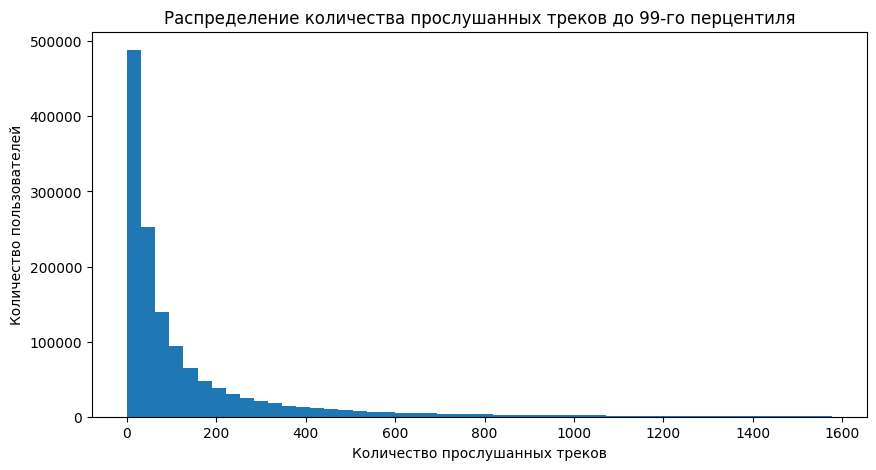

In [49]:
# строим распределение количества прослушанных треков
plt.figure(figsize=(10, 5))
plt.hist(
    listen_counts_main,
    bins=50)
plt.title("Распределение количества прослушанных треков до 99-го перцентиля")
plt.xlabel("Количество прослушанных треков")
plt.ylabel("Количество пользователей");

Распределение имеет выраженную правостороннюю асимметрию: основная часть пользователей прослушала сравнительно небольшое количество треков, тогда как небольшая доля пользователей значительно активнее остальных.

## Наиболее популярные треки

Определим наиболее популярные треки по количеству пользователей, которые их прослушали. Для обработки большого файла взаимодействий будем последовательно агрегировать количество прослушиваний по `track_id`, не загружая весь набор данных в память.

In [50]:
# создаём счётчик количества прослушиваний для каждого трека
track_listen_counts = pd.Series(dtype="int64")

In [51]:
# последовательно читаем только идентификаторы треков небольшими пакетами
for batch in interactions_parquet.iter_batches(
    batch_size=1000000,
    columns=["track_id"]
):
    batch_tracks = batch.column("track_id").to_pandas()
    # считаем количество прослушиваний треков внутри текущего пакета
    batch_counts = batch_tracks.value_counts()

    # добавляем результаты текущего пакета к общему счётчику
    track_listen_counts = track_listen_counts.add(
        batch_counts,
        fill_value=0)

In [52]:
# приводим итоговые значения к целочисленному типу
track_listen_counts = track_listen_counts.astype("int64")

In [53]:
# выводим результаты
print("Количество прослушанных треков:", len(track_listen_counts))
print("Максимальное количество слушателей одного трека:", track_listen_counts.max())

Количество прослушанных треков: 1000000
Максимальное количество слушателей одного трека: 111062


В данных о взаимодействиях встречается 1 млн различных треков. Максимальная аудитория одного трека составляет 111062 пользователя. Перед анализом самых популярных треков проверим согласованность полученной агрегации с исходными данными.

In [54]:
# проверяем, что сумма прослушиваний совпадает с общим количеством взаимодействий
print("Всего взаимодействий:", interactions_parquet.metadata.num_rows)
print("Сумма прослушиваний по трекам:", track_listen_counts.sum())
print("Количество треков в каталоге:", tracks["track_id"].nunique())
print("Количество треков с прослушиваниями:", len(track_listen_counts))

Всего взаимодействий: 222629898
Сумма прослушиваний по трекам: 222629898
Количество треков в каталоге: 1000000
Количество треков с прослушиваниями: 1000000


In [55]:
# проверяем совпадение идентификаторов треков в каталоге и взаимодействиях
print("Все треки из каталога встречаются во взаимодействиях:", pd.Index(tracks["track_id"]).difference(track_listen_counts.index).empty)

Все треки из каталога встречаются во взаимодействиях: True


Сумма прослушиваний по всем трекам полностью совпадает с общим количеством взаимодействий, равным 222 629 898. Все 1 млн треков из каталога встречаются во взаимодействиях, поэтому на текущем наборе данных непрослушанных треков нет. Теперь выведем треки с наибольшим количеством слушателей и добавим их названия из каталога для более интерпретируемого представления результатов.

In [56]:
# выбираем 10 самых популярных треков
top_tracks = (
    track_listen_counts
    .sort_values(ascending=False)
    .head(10)
    .rename("listeners")
    .reset_index()
    .rename(columns={"index": "track_id"})
)

In [57]:
# добавляем названия треков из каталога
top_tracks = top_tracks.merge(
    catalog_names.loc[
        catalog_names["type"] == "track",
        ["id", "name"]
    ],
    left_on="track_id",
    right_on="id",
    how="left"
)

In [58]:
# оставляем только нужные столбцы
top_tracks = top_tracks[["track_id", "name", "listeners"]]

In [59]:
# выводим результат
display(top_tracks)

,track_id,name,listeners
0,53404,Smells Like Teen Spirit,111062
1,33311009,Believer,106921
2,178529,Numb,101924
3,35505245,I Got Love,99490
4,65851540,Юность,86670
5,24692821,Way Down We Go,86246
6,32947997,Shape of You,85886
7,51241318,In The End,85244
8,795836,Shape Of My Heart,85042
9,45499814,Life,84748


Среди наиболее популярных треков лидирует `Smells Like Teen Spirit` с 111062 слушателями. В топ-10 входят как международные хиты, так и русскоязычные композиции, что указывает на разнообразие музыкальных предпочтений пользователей.

## Наиболее популярные жанры

Чтобы определить наиболее популярные жанры, суммируем количество прослушиваний всех треков, относящихся к каждому жанру. Поскольку один трек может принадлежать нескольким жанрам, его прослушивания учитываются для каждого указанного жанра.

In [60]:
# создаём счётчик прослушиваний по жанрам
genre_listen_counts = {}

In [61]:
# распределяем количество прослушиваний каждого трека по его жанрам
for track_id, genre_ids in tracks.set_index("track_id")["genres"].items():
    listeners = track_listen_counts.get(track_id, 0)

    for genre_id in genre_ids:
        genre_listen_counts[genre_id] = (genre_listen_counts.get(genre_id, 0) + listeners)

In [62]:
# преобразуем результат в Series для дальнейшего анализа
genre_listen_counts = pd.Series(genre_listen_counts, dtype="int64").sort_values(ascending=False)

In [63]:
# выводим результаты
print("Количество жанров с прослушиваниями:", len(genre_listen_counts))
print("Максимальное суммарное количество прослушиваний жанра:", genre_listen_counts.iloc[0])

Количество жанров с прослушиваниями: 143
Максимальное суммарное количество прослушиваний жанра: 55578312


В данных представлены 143 жанра с прослушиваниями. Самый популярный жанр суммарно набрал 55 578 312 прослушиваний, что указывает на заметную концентрацию пользовательского интереса вокруг наиболее востребованных жанров. Далее добавим к агрегированным данным названия жанров из каталога и выведем десять жанров с наибольшим суммарным количеством прослушиваний.

In [64]:
# формируем таблицу с самыми популярными жанрами
top_genres = (
    genre_listen_counts
    .head(10)
    .rename("listeners")
    .reset_index()
    .rename(columns={"index": "genre_id"})
)

In [65]:
# добавляем названия жанров из каталога
top_genres = top_genres.merge(
    catalog_names.loc[
        catalog_names["type"] == "genre",
        ["id", "name"]
    ],
    left_on="genre_id",
    right_on="id",
    how="left"
)

In [66]:
# оставляем только нужные столбцы
top_genres = top_genres[["genre_id", "name", "listeners"]]

In [67]:
# выводим результат
display(top_genres)

,genre_id,name,listeners
0,11,pop,55578312
1,75,rap,37799821
2,102,allrock,31092013
3,20,ruspop,26626241
4,3,rusrap,25303695
5,68,electronics,20120981
6,16,dance,16291557
7,2,rusrock,13166147
8,14,rock,12772644
9,47,metal,12437375


Наиболее популярным жанром является `pop`, его треки суммарно набрали 55 578 312 прослушиваний. Далее следуют `rap` и `allrock`. В топ-10 также входят русскоязычные жанры (`ruspop`, `rusrap`, `rusrock`), что подтверждает заметную долю русскоязычного музыкального контента в пользовательских предпочтениях.

## Треки, которые никто не прослушал

Проверим, есть ли в каталоге треки, для которых отсутствуют взаимодействия пользователей. Для этого сравним идентификаторы всех треков с идентификаторами треков, присутствующих в агрегированных данных о прослушиваниях.

In [68]:
# находим треки, которые отсутствуют среди взаимодействий
unlistened_tracks = tracks[~tracks["track_id"].isin(track_listen_counts.index)]

In [69]:
# выводим количество непрослушанных треков
print("Количество треков без прослушиваний:", len(unlistened_tracks))

Количество треков без прослушиваний: 0


Все треки хотя бы один раз встречаются во взаимодействиях пользователей, поэтому в текущем наборе данных нет треков без истории прослушиваний.

## Вывод по результатам EDA

- Анализ показал, что пользовательская активность распределена неравномерно: большинство пользователей прослушивает сравнительно небольшое количество треков, тогда как небольшая доля пользователей значительно активнее остальных. Это важно учитывать при обучении рекомендательной модели, поскольку активные пользователи могут сильнее влиять на структуру взаимодействий.
- Популярность треков и жанров также распределена неравномерно: часть объектов получает значительно больше прослушиваний. Поэтому при построении рекомендаций необходимо учитывать возможный перекос в сторону популярных объектов и отдельно оценивать персональные модели относительно простого популярностного бейзлайн.
- Все 1 млн треков встречаются во взаимодействиях, поэтому холодных объектов среди треков в текущем наборе нет. Повторных пар `user_id + track_id` также не обнаружено, следовательно каждое взаимодействие можно интерпретировать как уникальный факт прослушивания трека пользователем.

Таким образом, данные подходят для дальнейшего построения рекомендательной системы. Перед обучением моделей необходимо преобразовать данные в формат, удобный для расчётов рекомендаций: подготовить отдельный набор данных о треках и отдельный набор пользовательских взаимодействий, сохранив необходимые идентификаторы, признаки объектов и информацию о времени взаимодействий. Затем сохраним подготовленные данные в формате `parquet` для дальнейшего их использования на следующих этапах проекта.

# Преобразование данных

Подготовим отдельные наборы данных для дальнейших расчётов рекомендаций. Для треков сохраним очищенные данные из `tracks`, а для взаимодействий оставим только пользователь, трек, порядок взаимодействия и дату прослушивания, исключив технический индекс parquet-файла.

In [70]:
# подготавливаем данные о треках для дальнейшего использования
items = tracks.copy()

In [71]:
# задаём столбцы взаимодействий, необходимые для рекомендательной системы
event_columns = [
    "user_id",
    "track_id",
    "track_seq",
    "started_at",
]

In [72]:
# проверяем структуру подготовленных данных о треках
print("Размер items:", items.shape)
print("Столбцы items:", items.columns.tolist())

Размер items: (1000000, 4)
Столбцы items: ['track_id', 'albums', 'artists', 'genres']


In [73]:
# проверяем схему будущего набора взаимодействий
print("Столбцы events:", event_columns)

Столбцы events: ['user_id', 'track_id', 'track_seq', 'started_at']


Мы подготовили набор `items` размером 1 млн строк с 4 столбцами (с идентификаторами треков, альбомов, исполнителей и жанров). Для `events` определены 4 необходимых поля: `user_id`, `track_id`, `track_seq`, `started_at`; технический индекс parquet-файла в дальнейшие данные включать не будем.

Проверим дополнительно типы данных в подготовленных наборах.

In [74]:
# выводим типы данных подготовленного набора треков
print("Типы данных items:")
print(items.dtypes)

Типы данных items:
track_id     int32
albums      object
artists     object
genres      object
dtype: object


In [75]:
# выбираем из исходной схемы только поля будущего набора events
events_schema = {
    column: interactions_parquet.schema_arrow.field(column).type
    for column in event_columns
}

In [76]:
# выводим схему будущего набора взаимодействий
print("Схема events:")
for column, dtype in events_schema.items():
    print(f"{column}: {dtype}")

Схема events:
user_id: int32
track_id: int32
track_seq: int16
started_at: timestamp[ns]


Идентификаторы `track_id` в `items`, а также `user_id` и `track_id` в `events` уже имеют компактный тип `int32`. Порядковый номер взаимодействия хранится как `int16`, а дата как `timestamp`, поэтому дополнительные преобразования этих полей не требуются. Поля `albums`, `artists` и `genres` в pandas представлены как `object`, поскольку содержат списки идентификаторов.

Проверим тип элементов внутри списков `albums`, `artists` и `genres`, чтобы убедиться, что идентификаторы сущностей также имеют подходящий тип для дальнейшего хранения и расчётов.

In [77]:
# проверяем типы идентификаторов внутри списочных полей
for column in ["albums", "artists", "genres"]:
    non_empty_values = items.loc[
        items[column].apply(len) > 0,
        column
    ].iloc[0]

    print(
        f"{column}:",
        type(non_empty_values[0]),
        getattr(non_empty_values, "dtype", None)
    )

albums: <class 'numpy.int64'> int64
artists: <class 'numpy.int64'> int64
genres: <class 'numpy.int64'> None


Идентификаторы внутри списков `albums`, `artists` и `genres` имеют неоднородное представление и частично хранятся как `int64`. Поскольку диапазон всех идентификаторов в каталогах уже проверен и соответствует `int32`, приведём вложенные идентификаторы к единому компактному типу.

In [78]:
# приводим вложенные идентификаторы альбомов, исполнителей и жанров к int32
for column in ["albums", "artists", "genres"]:
    items[column] = items[column].apply(
        lambda ids: np.asarray(ids, dtype="int32")
    )

In [79]:
# проверяем результат преобразования
for column in ["albums", "artists", "genres"]:
    non_empty_values = items.loc[
        items[column].apply(len) > 0,
        column
    ].iloc[0]

    print(
        f"{column}:",
        type(non_empty_values[0]),
        non_empty_values.dtype
    )

albums: <class 'numpy.int32'> int32
artists: <class 'numpy.int32'> int32
genres: <class 'numpy.int32'> int32


Вложенные идентификаторы альбомов, исполнителей и жанров успешно приведены к типу `int32`. Теперь идентификаторы в `items` представлены единообразно и более компактно, при этом сами списочные поля и их содержимое сохранены. После преобразования проверим целостность набора `items`: количество строк, уникальность идентификаторов треков и наличие пропущенных идентификаторов.

In [80]:
# проверяем размер подготовленного набора треков
print("Размер items:", items.shape)

# проверяем уникальность идентификаторов треков
print("Количество уникальных track_id:", items["track_id"].nunique())

# проверяем наличие дубликатов идентификаторов треков
print("Дубликатов track_id:", items["track_id"].duplicated().sum())

# проверяем наличие пропусков в идентификаторах треков
print("Пропусков в track_id:", items["track_id"].isna().sum())

Размер items: (1000000, 4)
Количество уникальных track_id: 1000000
Дубликатов track_id: 0
Пропусков в track_id: 0


Набор `items` после преобразований сохранил весь 1 млн треков. Идентификаторы `track_id` уникальны, дубликаты и пропуски отсутствуют, поэтому целостность данных не нарушена. Переходим к сохранению данных.

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

Сохраним подготовленные наборы в формате parquet. `items` можно записать целиком, а большой набор `events` сформируем потоково из исходного файла, сохраняя только необходимые столбцы и исключая технический индекс.

In [81]:
# задаём пути для подготовленных parquet-файлов
items_output_path = Path("items.parquet")
events_output_path = Path("events.parquet")

In [82]:
# сохраняем подготовленные данные о треках без технического индекса pandas
items.to_parquet(
    items_output_path,
    index=False)

In [83]:
# потоково формируем файл взаимодействий
events_writer = None
try:
    for batch in interactions_parquet.iter_batches(
        batch_size=1_000_000,
        columns=event_columns
    ):
        # создаём writer по схеме первого пакета
        if events_writer is None:
            events_writer = pq.ParquetWriter(
                events_output_path,
                batch.schema            )
        # записываем очередной пакет взаимодействий
        events_writer.write_batch(batch)
finally:
    # гарантированно закрываем файл после записи
    if events_writer is not None:
        events_writer.close()

print("Локальный файл items.parquet создан:", items_output_path.exists())
print("Локальный файл events.parquet создан:", events_output_path.exists())

Локальный файл items.parquet создан: True
Локальный файл events.parquet создан: True


Локальные файлы `items.parquet` и `events.parquet` успешно созданы. Перед загрузкой в S3 необходимо проверить их целостность: количество строк, схему и размеры файлов.

In [84]:
# открываем сохранённые parquet-файлы через PyArrow
items_parquet = pq.ParquetFile(items_output_path)
events_parquet = pq.ParquetFile(events_output_path)

In [85]:
# выводим количество строк и столбцов
print(
    "items:",
    items_parquet.metadata.num_rows,
    "строк,",
    items_parquet.metadata.num_columns,
    "столбцов"
)
print(
    "events:",
    events_parquet.metadata.num_rows,
    "строк,",
    events_parquet.metadata.num_columns,
    "столбцов"
)

items: 1000000 строк, 4 столбцов
events: 222629898 строк, 4 столбцов


In [86]:
# выводим размеры файлов в мегабайтах
print(
    "Размер items.parquet:",
    round(items_output_path.stat().st_size / 1024**2, 2),
    "МБ"
)

print(
    "Размер events.parquet:",
    round(events_output_path.stat().st_size / 1024**2, 2),
    "МБ"
)

Размер items.parquet: 18.19 МБ
Размер events.parquet: 1004.43 МБ


Локальные parquet-файлы имеют ожидаемый объём данных: `items.parquet` содержит 1 млн треков и 4 столбца, а `events.parquet` 222 629 898 взаимодействий и 4 столбца. Размеры файлов составляют около 18.19 МБ и 1004.43 МБ соответственно, что выглядит согласованно с исходными данными и выбранной структурой.

Проверим схемы сохранённых parquet-файлов и убедимся, что типы идентификаторов, списочных полей и временных данных сохранились корректно.

In [87]:
# выводим схему сохранённого файла с треками
print("Схема items.parquet:")
print(items_parquet.schema_arrow)

Схема items.parquet:
track_id: int32
albums: list<element: int32>
  child 0, element: int32
artists: list<element: int32>
  child 0, element: int32
genres: list<element: int32>
  child 0, element: int32
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 538


In [88]:
# выводим схему сохранённого файла с взаимодействиями
print("Схема events.parquet:")
print(events_parquet.schema_arrow)

Схема events.parquet:
user_id: int32
track_id: int32
track_seq: int16
started_at: timestamp[ns]
-- schema metadata --
pandas: '{"index_columns": ["__index_level_0__"], "column_indexes": [{"na' + 797


Схемы сохранённых файлов соответствуют ожидаемой структуре: `items.parquet` содержит `track_id` и списочные идентификаторы в формате `int32`, а `events.parquet` 4 необходимых поля с исходными компактными типами. Технический индекс `__index_level_0__` отсутствует среди физических столбцов `events`. Упоминание о нём сохранилось только в служебных pandas-метаданных parquet-файла и не является отдельным столбцом данных.

Дополнительно проверим физические столбцы обоих parquet-файлов, чтобы убедиться, что технический индекс действительно не был сохранён как отдельное поле, а затем уже загрузим оба файла в S3.

In [89]:
# выводим физические имена столбцов сохранённых parquet-файлов
print("Столбцы items.parquet:", items_parquet.schema_arrow.names)
print("Столбцы events.parquet:", events_parquet.schema_arrow.names)

Столбцы items.parquet: ['track_id', 'albums', 'artists', 'genres']
Столбцы events.parquet: ['user_id', 'track_id', 'track_seq', 'started_at']


Физические столбцы обоих parquet-файлов полностью соответствуют ожидаемой структуре. Технический индекс в данные не попал: `items.parquet` содержит только `track_id`, `albums`, `artists`, `genres`, а `events.parquet` - `user_id`, `track_id`, `track_seq`, `started_at`. Переходим к загрузке файлов в S3-бакет по пути `recsys/data/`.

In [90]:
# загружаем переменные окружения с параметрами доступа к S3
load_dotenv(dotenv_path=".env")

True

In [91]:
# создаём клиент для работы с S3
s3_client = boto3.client(
    "s3",
    endpoint_url="https://storage.yandexcloud.net",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
)

In [92]:
# получаем имя персонального бакета из переменных окружения
s3_bucket = os.getenv("S3_BUCKET_NAME")

In [93]:
# задаём ключи для сохранения файлов
items_s3_key = "recsys/data/items.parquet"
events_s3_key = "recsys/data/events.parquet"

In [94]:
# загружаем подготовленные parquet-файлы в S3
s3_client.upload_file(
    str(items_output_path),
    s3_bucket,
    items_s3_key
)

s3_client.upload_file(
    str(events_output_path),
    s3_bucket,
    events_s3_key
)

print("Файлы загружены в S3.")

Файлы загружены в S3.


Подготовленные файлы `items.parquet` и `events.parquet` загружены в персональный S3-бакет по пути `recsys/data/`. Следующим шагом проверим их наличие, размеры и корректность сохранения уже непосредственно в бакете.

In [95]:
# задаём локальные пути и соответствующие ключи объектов в S3
s3_files = {
    items_s3_key: items_output_path,
    events_s3_key: events_output_path,
}

In [96]:
# проверяем каждый загруженный файл
for s3_key, local_path in s3_files.items():
    # получаем метаданные объекта из S3
    response = s3_client.head_object(
        Bucket=s3_bucket,
        Key=s3_key
    )

    remote_size = response["ContentLength"]
    local_size = local_path.stat().st_size

    # читаем первые четыре байта удалённого файла
    start_bytes = s3_client.get_object(
        Bucket=s3_bucket,
        Key=s3_key,
        Range="bytes=0-3"
    )["Body"].read()

    # читаем последние четыре байта удалённого файла
    end_bytes = s3_client.get_object(
        Bucket=s3_bucket,
        Key=s3_key,
        Range=f"bytes={remote_size - 4}-{remote_size - 1}"
    )["Body"].read()

    # выводим результаты проверки
    print(f"\n{s3_key}")
    print("Объект существует: True")
    print("Размер совпадает с локальным файлом:", remote_size == local_size)
    print("Сигнатура parquet в начале:", start_bytes == b"PAR1")
    print("Сигнатура parquet в конце:", end_bytes == b"PAR1")


recsys/data/items.parquet
Объект существует: True
Размер совпадает с локальным файлом: True
Сигнатура parquet в начале: True
Сигнатура parquet в конце: True

recsys/data/events.parquet
Объект существует: True
Размер совпадает с локальным файлом: True
Сигнатура parquet в начале: True
Сигнатура parquet в конце: True


Оба файла успешно сохранены в S3 и прошли проверку целостности. Размеры удалённых объектов полностью совпадают с локальными файлами, а сигнатура parquet корректна в начале и конце каждого файла. Проверим содержимое каталога `recsys/data/` в S3 и убедимся, что подготовленные файлы сохранены по ожидаемым ключам без дублирования.

In [97]:
# получаем список объектов в каталоге recsys/data/
response = s3_client.list_objects_v2(
    Bucket=s3_bucket,
    Prefix="recsys/data/")

In [98]:
# выводим найденные объекты
for obj in response.get("Contents", []):
    print(
        obj["Key"],
        "-",
        round(obj["Size"] / 1024**2, 2),
        "МБ"
    )

recsys/data/events.parquet - 1004.43 МБ
recsys/data/items.parquet - 18.19 МБ


В каталоге `recsys/data/` находятся ровно два ожидаемых объекта: `events.parquet` и `items.parquet`. Их размеры совпадают с локальными файлами, дополнительных копий или неожиданных дублей не обнаружено.

# Очистка памяти

После завершения подготовки и сохранения данных освободим память от промежуточных объектов, которые больше не понадобятся на текущем этапе.

In [99]:
# удаляем промежуточные объекты, которые больше не нужны
del top_tracks
del top_genres
del unlistened_tracks
del genre_listen_counts
del user_listen_counts
del track_listen_counts
del items_parquet
del events_parquet
del events_schema

In [100]:
# запускаем сборщик мусора
gc.collect()

10550

Таким образом, промежуточные объекты, использованные для EDA и проверок, удалены из памяти. Основные данные сохранены в S3. Переходим непосредственно к созданию рекомендательной системы.

# Выводы

- На этапе анализа данных были исследованы распределение количества прослушанных треков, наиболее популярные треки и жанры, а также наличие непрослушанных треков.
- Пользовательская активность распределена неравномерно: медианное количество прослушанных треков составляет 55, тогда как среднее 162.12, что указывает на выраженную правостороннюю асимметрию и наличие небольшой группы очень активных пользователей. Среди треков наиболее популярным оказался `Smells Like Teen Spirit` с 111062 слушателями. Среди жанров лидирует `pop` с 55 578 312 суммарными прослушиваниями. Непрослушанных треков в каталоге не обнаружено: все 1 млн треков встречаются во взаимодействиях пользователей.
- Для дальнейшего обучения данные были приведены к более компактному и согласованному формату. Идентификаторы треков, альбомов, исполнителей и жанров в `items` представлены в формате `int32`, а `events` содержит поля `user_id`, `track_id`, `track_seq` и `started_at`.
- Подготовленные наборы сохранены в `items.parquet` и `events.parquet` и загружены в персональный S3-бакет по пути `recsys/data/`. Проверка подтвердила наличие файлов в S3, совпадение их размеров с локальными версиями и корректность parquet-формата. При повторном запуске ноутбука файлы сохраняются по тем же ключам и перезаписывают предыдущие версии без создания дублей.
- После завершения анализа и сохранения данных промежуточные объекты были удалены из памяти, а сборщик мусора освободил дополнительные неиспользуемые объекты. Это уменьшает нагрузку на память перед переходом к следующему этапу проекта. 

Таким образом, данные подготовлены к следующему этапу - построению и оценке моделей рекомендаций.

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.